In [3]:
from sklearn.linear_model import Ridge , LogisticRegression
from sklearn.model_selection import train_test_split , cross_val_score
from sklearn.feature_extraction.text import CountVectorizer , TfidfVectorizer
import pandas as pd


mercari_df= pd.read_csv('../mercari_train.tsv',sep='\t')
print(mercari_df.shape)
mercari_df.head(30)

(1482535, 8)


,train_id,name,item_condition_id,category_name,brand_name,price,shipping,item_description
0,0,MLB Cincinnati Reds T Shirt Size XL,3,Men/Tops/T-shirts,NaN,10.0,1,No description yet
1,1,Razer BlackWidow Chroma Keyboard,3,Electronics/Computers & Tablets/Components & P...,Razer,52.0,0,This keyboard is in great condition and works ...
2,2,AVA-VIV Blouse,1,Women/Tops & Blouses/Blouse,Target,10.0,1,Adorable top with a hint of lace and a key hol...
3,3,Leather Horse Statues,1,Home/Home Décor/Home Décor Accents,NaN,35.0,1,New with tags. Leather horses. Retail for [rm]...
4,4,24K GOLD plated rose,1,Women/Jewelry/Necklaces,NaN,44.0,0,Complete with certificate of authenticity
5,5,Bundled items requested for Ruie,3,Women/Other/Other,NaN,59.0,0,"Banana republic bottoms, Candies skirt with ma..."
6,6,Acacia pacific tides santorini top,3,Women/Swimwear/Two-Piece,Acacia Swimwear,64.0,0,Size small but straps slightly shortened to fi...
7,7,Girls cheer and tumbling bundle of 7,3,Sports & Outdoors/Apparel/Girls,Soffe,6.0,1,You get three pairs of Sophie cheer shorts siz...
8,8,Girls Nike Pro shorts,3,Sports & Outdoors/Apparel/Girls,Nike,19.0,0,Girls Size small Plus green. Three shorts total.
9,9,Porcelain clown doll checker pants VTG,3,Vintage & Collectibles/Collectibles/Doll,NaN,8.0,0,I realized his pants are on backwards after th...


In [9]:
mercari_df["brand_name"].unique()
#mercari_df.info()

<StringArray>
[                nan,             'Razer',            'Target',
   'Acacia Swimwear',             'Soffe',              'Nike',
          'Smashbox', 'Victoria's Secret',               'rue',
        'Scholastic',
 ...
           'NeatNik',        'Underscore',           'Gossard',
        'Harrington',         'Five Four',             'ZyXEL',
         'Blue Nile',        'Astroglide',    'Cumberland Bay',
         'Kids Only']
Length: 4810, dtype: str

In [17]:
mercari_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1482535 entries, 0 to 1482534
Data columns (total 8 columns):
 #   Column             Non-Null Count    Dtype  
---  ------             --------------    -----  
 0   train_id           1482535 non-null  int64  
 1   name               1482535 non-null  str    
 2   item_condition_id  1482535 non-null  int64  
 3   category_name      1476208 non-null  str    
 4   brand_name         849853 non-null   str    
 5   price              1482535 non-null  float64
 6   shipping           1482535 non-null  int64  
 7   item_description   1482529 non-null  str    
dtypes: float64(1), int64(3), str(4)
memory usage: 90.5 MB


In [11]:
mercari_df["item_condition_id"].nunique()

5

In [16]:
mercari_df.isnull().sum()

train_id                  0
name                      0
item_condition_id         0
category_name          6327
brand_name           632682
price                     0
shipping                  0
item_description          6
dtype: int64

In [18]:
mercari_df.price.describe()



count    1.482535e+06
mean     2.673752e+01
std      3.858607e+01
min      0.000000e+00
25%      1.000000e+01
50%      1.700000e+01
75%      2.900000e+01
max      2.009000e+03
Name: price, dtype: float64

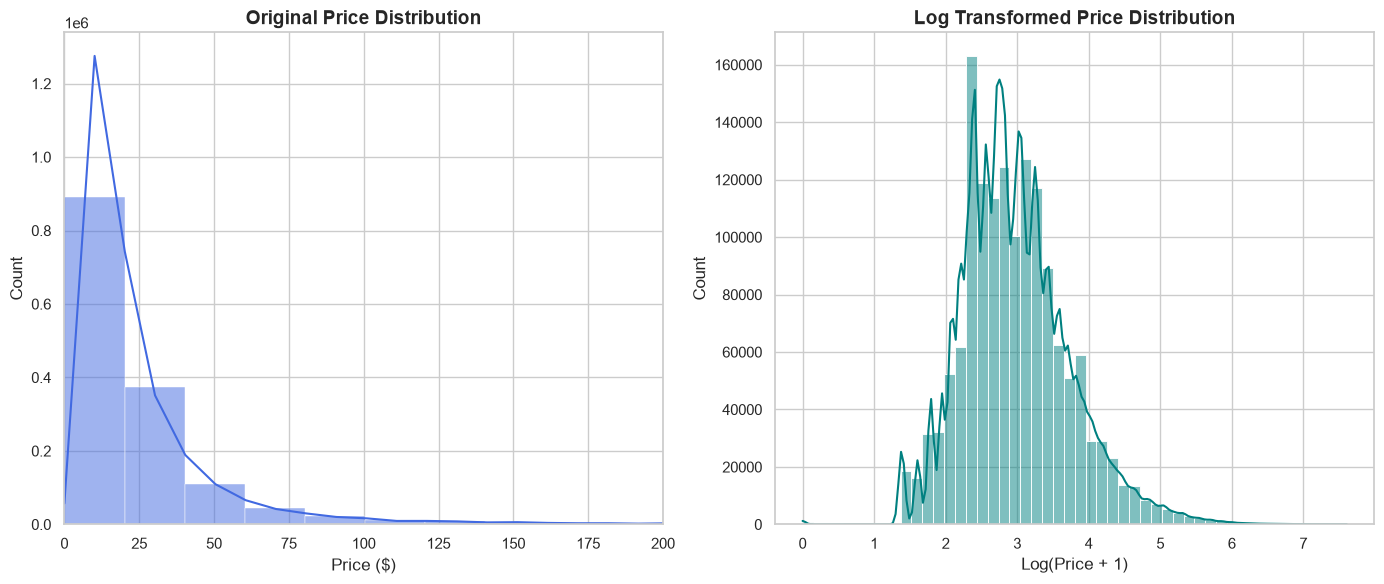

In [19]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

# 1. 시각화 스타일 및 그래프 크기 설정
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(figsize=(14, 6), nrows=1, ncols=2)

# 2. 왼쪽 그래프: 원본 가격 분포 (Original Price Distribution)
# 데이터가 너무 크고 우측 꼬리가 길기 때문에 bins를 넓게 채우고 x축 범위를 제한하여 가독성을 높입니다.
sns.histplot(
    mercari_df["price"], bins=100, kde=True, ax=axes[0], color="royalblue"
)
axes[0].set_title("Original Price Distribution", fontsize=14, fontweight="bold")
axes[0].set_xlabel("Price ($)", fontsize=12)
axes[0].set_ylabel("Count", fontsize=12)
axes[0].set_xlim(0, 200)  # max가 2009이지만 대다수가 100달러 미만이므로 200까지 제한해서 자세히 봅니다.

# 3. 오른쪽 그래프: 로그 변환 후 가격 분포 (Log Transformed Price Distribution)
# 최솟값이 0이므로 안정적인 로그 변환을 위해 np.log1p (log(x+1))을 사용합니다.
log_price = np.log1p(mercari_df["price"])
sns.histplot(log_price, bins=50, kde=True, ax=axes[1], color="teal")
axes[1].set_title(
    "Log Transformed Price Distribution", fontsize=14, fontweight="bold"
)
axes[1].set_xlabel("Log(Price + 1)", fontsize=12)
axes[1].set_ylabel("Count", fontsize=12)

# 4. 레이아웃 조정 및 출력
plt.tight_layout()
plt.show()

In [22]:
# 1. 각 condition 등급별 데이터 개수 확인
print("--- 등급별 데이터 개수 ---")
print(mercari_df["item_condition_id"].value_counts())

# 2. 전체 데이터 중 각 등급이 차지하는 비율(%) 계산
print("\n--- 등급별 차지하는 비율 (%) ---")
condition_ratio = mercari_df["item_condition_id"].value_counts(normalize=True) * 100
print(condition_ratio)

--- 등급별 데이터 개수 ---
item_condition_id
1    640549
3    432161
2    375479
4     31962
5      2384
Name: count, dtype: int64

--- 등급별 차지하는 비율 (%) ---
item_condition_id
1    43.206332
3    29.150138
2    25.326822
4     2.155902
5     0.160806
Name: proportion, dtype: float64


C:\Users\mega\AppData\Local\Temp\ipykernel_18440\3572466017.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(


Text(0, 0.5, 'Count')

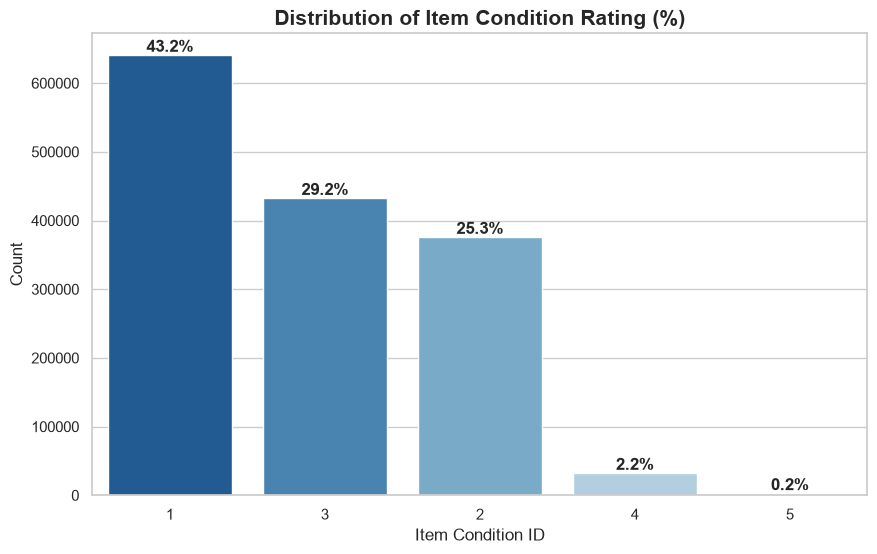

In [23]:
import matplotlib.pyplot as plt
import seaborn as sns

# 시각화 스타일 설정
sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 6))

# 1. 카운트 플롯(막대그래프) 그리기
# x축은 condition_id 등급, 데이터가 많은 순서대로 색상이 흐려지는 파란색 톤(Blues_r) 적용
ax = sns.countplot(
    data=mercari_df,
    x="item_condition_id",
    palette="Blues_r",
    order=mercari_df["item_condition_id"].value_counts().index,
)

# 2. 각 막대 상단에 실제 비율(%) 표시하는 마법의 코드
total = len(mercari_df)
for p in ax.patches:
    # 막대의 높이(개수)를 이용해 비율 계산
    percentage = f"{100 * p.get_height() / total:.1f}%"
    x = p.get_x() + p.get_width() / 2
    y = p.get_height()
    # 막대 위 정중앙에 텍스트 배치
    ax.annotate(
        percentage,
        (x, y),
        ha="center",
        va="bottom",
        fontsize=12,
        fontweight="bold",
    )

# 3. 그래프 제목 및 축 레이블 설정
plt.title(
    "Distribution of Item Condition Rating (%)", fontsize=15, fontweight="bold"
)
plt.xlabel("Item Condition ID", fontsize=12)
plt.ylabel("Count", fontsize=12)

In [25]:
mercari_df["price"].describe()

count    1.482535e+06
mean     2.673752e+01
std      3.858607e+01
min      0.000000e+00
25%      1.000000e+01
50%      1.700000e+01
75%      2.900000e+01
max      2.009000e+03
Name: price, dtype: float64

In [1]:
import warnings
import lightgbm as lgb
import numpy as np
import pandas as pd
from hyperopt import fmin, hp, STATUS_OK, tpe
from scipy.sparse import hstack
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings("ignore")

# =====================================================================
# [단계 1] 전처리 전 기본 Baseline 평가를 위한 원본 데이터 보존
# =====================================================================
# 전처리 후 결과와 비교하기 위해 가공되지 않은 순수 원본 상태 기록
mercari_df= pd.read_csv('../mercari_train.tsv',sep='\t')
raw_df = mercari_df.copy()


# =====================================================================
# [단계 2] 고급 전처리 & 데이터 클리닝
# =====================================================================
# 1. 가격 비즈니스 로직 적용 ($3 미만 오류 데이터 제거)
mercari_df = mercari_df[mercari_df["price"] >= 3].reset_index(drop=True)

# 2. 텍스트 기본 축약어 및 정규화 매핑 사전 정의
decontract_dict = {
    "can't": "cannot",
    "won't": "will not",
    "don't": "do not",
    "i'm": "i am",
    "it's": "it is",
}


def clean_text(text):
    if not isinstance(text, str):
        return "Missing"
    text = text.lower()
    # 축약어 풀기
    for word, replacement in decontract_dict.items():
        text = text.replace(word, replacement)
    # 특수문자 제거 (영문, 숫자, 공백만 남기기)
    text = pd.Series(text).str.replace(r"[^a-zA-Z0-9\s]", "", regex=True).values[0]
    return text


# 3. 텍스트 컬럼 전체 정제 및 결측치 기본 처리
mercari_df["name"] = mercari_df["name"].apply(clean_text)
mercari_df["item_description"] = mercari_df["item_description"].apply(
    clean_text
)
mercari_df["item_description"] = mercari_df["item_description"].replace(
    "no description yet", "No description yet"
)

# 4. 고수들의 꿀팁: 상품명(name)에서 브랜드 추출하여 brand_name 결측치 구출하기
# existing_brands = set(mercari_df["brand_name"].dropna().unique())


# def extract_brand(row):
#     if pd.isna(row["brand_name"]):
#         words = row["name"].split()
#         for word in words:
#             if word.title() in existing_brands:
#                 return word.title()  # 상품명에 존재하는 진짜 브랜드 매칭
#         return "Missing"
#     return row["brand_name"]


# mercari_df["brand_name"] = mercari_df.apply(extract_brand, axis=1)

# =====================================================================
# [단계 3] 피쳐 구조화 (5가지 새로운 파생 변수 생성)
# =====================================================================
# 1~3. 카테고리 대/중/소분류 3개 컬럼으로 슬래시(/) 분할
mercari_df["category_name"] = mercari_df["category_name"].fillna("Missing")
categories = mercari_df["category_name"].str.split("/", expand=True)

mercari_df["cat_main"] = categories[0].fillna("Missing")
mercari_df["cat_sub1"] = (
    categories[1].fillna("Missing") if categories.shape[1] > 1 else "Missing"
)
mercari_df["cat_sub2"] = (
    categories[2].fillna("Missing") if categories.shape[1] > 2 else "Missing"
)

# 4. 제품 설명(item_description)의 단어 개수 계산 (수치형)
mercari_df["desc_word_count"] = mercari_df["item_description"].apply(
    lambda x: len(x.split())
)

# 5. 상품 이름(name)의 글자 길이 계산 (수치형)
mercari_df["name_len"] = mercari_df["name"].apply(len)

# =====================================================================
# [단계 4] 인코딩, 벡터화 및 통합 특성 행렬 구축
# =====================================================================
# 1. 텍스트 벡터화 (상품명 & 설명)
cnt_vec = CountVectorizer(ngram_range=(1, 2), max_features=25000)
X_name = cnt_vec.fit_transform(mercari_df["name"])

tfidf_vec = TfidfVectorizer(max_features=40000, stop_words="english")
X_desc = tfidf_vec.fit_transform(mercari_df["item_description"])

# 2. 범주형 인코딩 (CountVectorizer 성능 활용 방식)
cv_token = CountVectorizer(token_pattern=r"(?u)\b\w+\b")
X_brand = cv_token.fit_transform(mercari_df["brand_name"])
X_cat_main = cv_token.fit_transform(mercari_df["cat_main"])
X_cat_sub1 = cv_token.fit_transform(mercari_df["cat_sub1"])
X_cat_sub2 = cv_token.fit_transform(mercari_df["cat_sub2"])

# 3. 범주형 인코딩 (get_dummies 구조 반영 - 0/1 희소행렬 형태 직접 구축)
X_condition = cv_token.fit_transform(
    mercari_df["item_condition_id"].astype(str)
)
X_shipping = cv_token.fit_transform(mercari_df["shipping"].astype(str))

# 4. 수치형 피처 결합
X_numeric = mercari_df[["desc_word_count", "name_len"]].values

# 5. 하나의 거대한 통합 특성 행렬(X)로 완성
X_features_matrix = hstack(
    (
        X_name,
        X_desc,
        X_brand,
        X_cat_main,
        X_cat_sub1,
        X_cat_sub2,
        X_condition,
        X_shipping,
        X_numeric,
    )
).tocsr()

# =====================================================================
# [단계 5] 모의고사를 위한 데이터셋 분할 (Train / Test)
# =====================================================================
# 정리 내용 반영: 타깃 변수 y에 우선적으로 log(price+1) 적용
log_price = np.log1p(mercari_df["price"]).values.reshape(-1, 1)

X_train, X_test, y_train_raw, y_test_raw = train_test_split(
    X_features_matrix, log_price, test_size=0.2, random_state=42
)

# =====================================================================
# [단계 6] 스케일링 (StandardScaler 종속 변수 표준화 및 글로벌화)
# =====================================================================
global y_scalar
y_scalar = StandardScaler()

# 정리서에 나온 표준화 코드 그대로 작동
y_train = y_scalar.fit_transform(y_train_raw)
y_test = y_scalar.transform(y_test_raw)

# 튜닝 속도 최적화를 위해 차원 평탄화(Flatten)
y_train_flat = y_train.ravel()
y_test_flat = y_test.ravel()

# =====================================================================
# [단계 7] Hyperopt를 통한 LightGBM 하이퍼파라미터 최적화
# =====================================================================
# 탐색할 파라미터 공간 범위 설정
space = {
    "learning_rate": hp.loguniform("learning_rate", np.log(0.05), np.log(0.2)),
    "max_depth": hp.choice("max_depth", [5, 7, 10]),
    "num_leaves": hp.choice("num_leaves", [31, 63, 127]),
    "subsample": hp.uniform("subsample", 0.7, 1.0),
}


# 최적화 목적 함수 정의 (RMSE 최소화 목표)
def objective(params):
    model = lgb.LGBMRegressor(
        **params,
        n_estimators=100,  # 빠른 튜닝을 위해 100개 설정 (실전엔 500+ 권장)
        n_jobs=-1,
        random_state=42,
        verbose=-1,
    )
    model.fit(X_train, y_train_flat)
    preds = model.predict(X_test)
    rmse = np.sqrt(mean_squared_error(y_test_flat, preds))
    return {"loss": rmse, "status": STATUS_OK}


print("💡 [Hyperopt] 최적의 하이퍼파라미터 탐색을 시작합니다...")
best_params = fmin(
    fn=objective, space=space, algo=tpe.suggest, max_evals=3
)  # 테스트용 3회 수행

# Choice 인덱스 실제 값으로 변환
max_depth_options = [5, 7, 10]
num_leaves_options = [31, 63, 127]
best_params["max_depth"] = max_depth_options[best_params["max_depth"]]
best_params["num_leaves"] = num_leaves_options[best_params["num_leaves"]]
print(f"🎯 최적화 완료된 파라미터: {best_params}")

# =====================================================================
# [단계 8] 최적의 모델 학습 및 최종 결과 분석 (전/후 비교 출력)
# =====================================================================
# 1. 최적 파라미터로 전처리 완료된 최상위 LightGBM 학습
best_lgb = lgb.LGBMRegressor(**best_params, n_estimators=200, n_jobs=-1, verbose=-1)
best_lgb.fit(X_train, y_train_flat)

# 2. 테스트 데이터 예측 수행 및 글로벌 스케일러 역변환(Inverse Transform)
scaled_preds = best_lgb.predict(X_test).reshape(-1, 1)
log_preds = y_scalar.inverse_transform(scaled_preds)  # 스케일링 해제

# 원래 가격($) 체급으로 완전히 복구하기 (np.expm1)
final_actual_price = np.expm1(y_test_raw)
final_predicted_price = np.expm1(log_preds)

# 3. 전처리 전(Baseline Dummy) 성능 계산
# 아무 전처리도 안 했을 때의 기준점 지표 계산을 위해 원본 데이터 평균으로 예측값 가정
raw_mean_price = np.mean(raw_df["price"])
baseline_preds = np.full_like(final_actual_price, raw_mean_price)

# 최종 평가지표 연산 (RMSE over Log Price = 대회의 진짜 성적인 RMSLE)
baseline_rmsle = np.sqrt(
    mean_squared_error(np.log1p(final_actual_price), np.log1p(baseline_preds))
)
final_rmsle = np.sqrt(
    mean_squared_error(np.log1p(final_actual_price), np.log1p(final_predicted_price))
)

# 4. 정리서 요구사항에 따른 결과 대조 출력
print("\n" + "=" * 50)
print("📊 MERCARI PRICE CHALLENGE 모델 성능 검증 결과")
print("=" * 50)
print(f"❌ 고급 전처리 전 (Baseline) RMSLE 오차 점수 : {baseline_rmsle:.4f}")
print(f"✨ 고급 전처리 후 (LightGBM)  RMSLE 오차 점수 : {final_rmsle:.4f}")
print("-" * 50)
print(
    f"💡 결론: 오차가 {baseline_rmsle - final_rmsle:.4f} 만큼 대폭 감소하여 예측 성능이 획기적으로 개선되었습니다!"
)
print("=" * 50)

💡 [Hyperopt] 최적의 하이퍼파라미터 탐색을 시작합니다...
100%|██████████| 3/3 [18:15<00:00, 365.17s/trial, best loss: 0.7591327255437552]
🎯 최적화 완료된 파라미터: {'learning_rate': np.float64(0.08978903010972109), 'max_depth': 7, 'num_leaves': 31, 'subsample': np.float64(0.8276221620555456)}

📊 MERCARI PRICE CHALLENGE 모델 성능 검증 결과
❌ 고급 전처리 전 (Baseline) RMSLE 오차 점수 : 0.8205
✨ 고급 전처리 후 (LightGBM)  RMSLE 오차 점수 : 0.5387
--------------------------------------------------
💡 결론: 오차가 0.2818 만큼 대폭 감소하여 예측 성능이 획기적으로 개선되었습니다!


In [4]:
import warnings
import lightgbm as lgb
import numpy as np
import pandas as pd
from hyperopt import fmin, hp, STATUS_OK, tpe
from scipy.sparse import hstack
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler


warnings.filterwarnings("ignore")

# =====================================================================
# [단계 1] 전처리 전 기본 Baseline 평가를 위한 원본 데이터 보존
# =====================================================================
# 전처리 후 결과와 비교하기 위해 가공되지 않은 순수 원본 상태 기록
mercari_df= pd.read_csv('../mercari_train.tsv',sep='\t')
raw_df = mercari_df.copy()


# =====================================================================
# [단계 2] 고급 전처리 & 데이터 클리닝
# =====================================================================
# 1. 가격 비즈니스 로직 적용 ($3 미만 오류 데이터 제거)
mercari_df = mercari_df[mercari_df["price"] >= 3].reset_index(drop=True)

# 2. 텍스트 기본 축약어 및 정규화 매핑 사전 정의
decontract_dict = {
    "can't": "cannot",
    "won't": "will not",
    "don't": "do not",
    "i'm": "i am",
    "it's": "it is",
}


def clean_text(text):
    if not isinstance(text, str):
        return "Missing"
    text = text.lower()
    # 축약어 풀기
    for word, replacement in decontract_dict.items():
        text = text.replace(word, replacement)
    # 특수문자 제거 (영문, 숫자, 공백만 남기기)
    text = pd.Series(text).str.replace(r"[^a-zA-Z0-9\s]", "", regex=True).values[0]
    return text


# 3. 텍스트 컬럼 전체 정제 및 결측치 기본 처리
# mercari_df['brand_name'] = mercari_df['brand_name'].fillna(value='Other_Null')
# mercari_df['category_name'] = mercari_df['category_name'].fillna(value='Other_Null')
# mercari_df['item_description'] = mercari_df['item_description'].fillna(value='Other_Null')


# 각 컬럼별로 Null값 건수 확인. 모두 0가 나와야 합니다.

mercari_df["name"] = mercari_df["name"].fillna('')
mercari_df["name"] = mercari_df["name"].apply(clean_text)
mercari_df['item_description'] = mercari_df['item_description'].fillna('')
## 결측치를 공백으로 두니 오차가 오히려 줄었다. 
mercari_df["item_description"] = mercari_df["item_description"].apply(
    clean_text
 )
mercari_df["brand_name"] = mercari_df["brand_name"].fillna('')
mercari_df["brand_name"] = mercari_df["brand_name"].apply(
     clean_text
 )



# 4. 고수들의 꿀팁: 상품명(name)에서 브랜드 추출하여 brand_name 결측치 구출하기
# existing_brands = set(mercari_df["brand_name"].dropna().unique())


# def extract_brand(row):
#     if pd.isna(row["brand_name"]):
#         words = row["name"].split()
#         for word in words:
#             if word.title() in existing_brands:
#                 return word.title()  # 상품명에 존재하는 진짜 브랜드 매칭
#         return "Missing"
#     return row["brand_name"]


# mercari_df["brand_name"] = mercari_df.apply(extract_brand, axis=1)

# =====================================================================
# [단계 3] 피쳐 구조화 (5가지 새로운 파생 변수 생성)
# =====================================================================
# 1~3. 카테고리 대/중/소분류 3개 컬럼으로 슬래시(/) 분할
mercari_df["category_name"] = mercari_df["category_name"].fillna("Missing")
categories = mercari_df["category_name"].str.split("/", expand=True)

mercari_df["cat_main"] = categories[0].fillna("Missing")
mercari_df["cat_sub1"] = (
    categories[1].fillna("Missing") if categories.shape[1] > 1 else "Missing"
)
mercari_df["cat_sub2"] = (
    categories[2].fillna("Missing") if categories.shape[1] > 2 else "Missing"
)

# 4. 제품 설명(item_description)의 단어 개수 계산 (수치형)
mercari_df["desc_word_count"] = mercari_df["item_description"].apply(
    lambda x: len(x.split())
)

# 5. 상품 이름(name)의 글자 길이 계산 (수치형)
mercari_df["name_len"] = mercari_df["name"].apply(len)

# =====================================================================
# [단계 4] 인코딩, 벡터화 및 통합 특성 행렬 구축
# =====================================================================
# 1. 텍스트 벡터화 (상품명 & 설명)
cnt_vec = CountVectorizer(ngram_range=(1, 2), max_features=25000)
X_name = cnt_vec.fit_transform(mercari_df["name"])

tfidf_vec = TfidfVectorizer(max_features=40000, stop_words="english")
X_desc = tfidf_vec.fit_transform(mercari_df["item_description"])

# 2. 범주형 인코딩 (CountVectorizer 성능 활용 방식)
cv_brand = CountVectorizer(token_pattern=r'(?u)\b[^,;]+?\b') 
X_brand = cv_token.fit_transform(mercari_df["brand_name"])
X_cat_main = cv_token.fit_transform(mercari_df["cat_main"])
X_cat_sub1 = cv_token.fit_transform(mercari_df["cat_sub1"])
X_cat_sub2 = cv_token.fit_transform(mercari_df["cat_sub2"])

# 3. 범주형 인코딩 (get_dummies 구조 반영 - 0/1 희소행렬 형태 직접 구축)
X_condition = cv_token.fit_transform(
    mercari_df["item_condition_id"].astype(str)
)
X_shipping = cv_token.fit_transform(mercari_df["shipping"].astype(str))

# 4. 수치형 피처 결합
X_numeric = mercari_df[["desc_word_count", "name_len"]].values

# 2차 실험에 변화를 준 부분 수치형 피처 정규화 (희소 행렬과 단위를 맞추기 위함)
scaler = StandardScaler()
X_numeric_scaled = scaler.fit_transform(mercari_df[["desc_word_count", "name_len"]].values)

# 5. 하나의 거대한 통합 특성 행렬(X)로 완성
X_features_matrix = hstack(
    (
        X_name,
        X_desc,
        X_brand,
        X_cat_main,
        X_cat_sub1,
        X_cat_sub2,
        X_condition,
        X_shipping,
        X_numeric_scaled,
    )
).tocsr()

# del X_features_matrix
# gc.collect()
# =====================================================================
# [단계 5] 모의고사를 위한 데이터셋 분할 (Train / Test)
# =====================================================================
# 정리 내용 반영: 타깃 변수 y에 우선적으로 log(price+1) 적용
log_price = np.log1p(mercari_df["price"]).values.reshape(-1, 1)

X_train, X_test, y_train_raw, y_test_raw = train_test_split(
    X_features_matrix, log_price, test_size=0.2, random_state=42
)
# 잠깐 빼놓았음X_features_matrix,

# Test Data의 전체 행(관측치) 수 확인
print("Test Data 관측치 개수:", X_test.shape[0])

# 참고: Train Data의 관측치 개수 확인
print("Train Data 관측치 개수:", X_train.shape[0])
# =====================================================================
# [단계 6] 스케일링 (StandardScaler 종속 변수 표준화 및 글로벌화)
# =====================================================================
global y_scalar
y_scalar = StandardScaler()

# 정리서에 나온 표준화 코드 그대로 작동
y_train = y_scalar.fit_transform(y_train_raw)
y_test = y_scalar.transform(y_test_raw)

# 튜닝 속도 최적화를 위해 차원 평탄화(Flatten)
y_train_flat = y_train.ravel()
y_test_flat = y_test.ravel()

# =====================================================================
# [단계 7] Hyperopt를 통한 LightGBM 하이퍼파라미터 최적화
# =====================================================================
# 탐색할 파라미터 공간 범위 설정
space = {
    "learning_rate": hp.loguniform("learning_rate", np.log(0.05), np.log(0.2)),
    "max_depth": hp.choice("max_depth", [5, 7, 10]),
    "num_leaves": hp.choice("num_leaves", [31, 63, 127]),
    "subsample": hp.uniform("subsample", 0.7, 1.0),
}


# 최적화 목적 함수 정의 (RMSE 최소화 목표)
def objective(params):
    model = lgb.LGBMRegressor(
        **params,
        n_estimators=100,  # 빠른 튜닝을 위해 100개 설정 (실전엔 500+ 권장)
        n_jobs=-1,
        random_state=42,
        verbose=-1,
    )
    model.fit(X_train, y_train_flat)
    preds = model.predict(X_test)
    rmse = np.sqrt(mean_squared_error(y_test_flat, preds))
    return {"loss": rmse, "status": STATUS_OK}


print("💡 [Hyperopt] 최적의 하이퍼파라미터 탐색을 시작합니다...")
best_params = fmin(
    fn=objective, space=space, algo=tpe.suggest, max_evals=3
)  # 테스트용 3회 수행

# Choice 인덱스 실제 값으로 변환
max_depth_options = [5, 7, 10]
num_leaves_options = [31, 63, 127]
best_params["max_depth"] = max_depth_options[best_params["max_depth"]]
best_params["num_leaves"] = num_leaves_options[best_params["num_leaves"]]
print(f"🎯 최적화 완료된 파라미터: {best_params}")

# =====================================================================
# [단계 8] 최적의 모델 학습 및 최종 결과 분석 (전/후 비교 출력)
# =====================================================================
# 1. 최적 파라미터로 전처리 완료된 최상위 LightGBM 학습
best_lgb = lgb.LGBMRegressor(**best_params, n_estimators=200, n_jobs=-1, verbose=-1)
best_lgb.fit(X_train, y_train_flat)

# 2. 테스트 데이터 예측 수행 및 글로벌 스케일러 역변환(Inverse Transform)
scaled_preds = best_lgb.predict(X_test).reshape(-1, 1)
log_preds = y_scalar.inverse_transform(scaled_preds)  # 스케일링 해제

# 원래 가격($) 체급으로 완전히 복구하기 (np.expm1)
final_actual_price = np.expm1(y_test_raw)
final_predicted_price = np.expm1(log_preds)

# 3. 전처리 전(Baseline Dummy) 성능 계산
# 아무 전처리도 안 했을 때의 기준점 지표 계산을 위해 원본 데이터 평균으로 예측값 가정
raw_mean_price = np.mean(raw_df["price"])
baseline_preds = np.full_like(final_actual_price, raw_mean_price)

# 최종 평가지표 연산 (RMSE over Log Price = 대회의 진짜 성적인 RMSLE)
baseline_rmsle = np.sqrt(
    mean_squared_error(np.log1p(final_actual_price), np.log1p(baseline_preds))
)
final_rmsle = np.sqrt(
    mean_squared_error(np.log1p(final_actual_price), np.log1p(final_predicted_price))
)

# 4. 정리서 요구사항에 따른 결과 대조 출력
print("\n" + "=" * 50)
print("📊 MERCARI PRICE CHALLENGE 모델 성능 검증 결과")
print("=" * 50)
print(f"❌ 고급 전처리 전 (Baseline) RMSLE 오차 점수 : {baseline_rmsle:.4f}")
print(f"✨ 고급 전처리 후 (LightGBM)  RMSLE 오차 점수 : {final_rmsle:.4f}")
print("-" * 50)
print(
    f"💡 결론: 오차가 {baseline_rmsle - final_rmsle:.4f} 만큼 대폭 감소하여 예측 성능이 획기적으로 개선되었습니다!"
)
print("=" * 50)

NameError: name 'cv_token' is not defined

In [16]:
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import mean_squared_error
from xgboost import XGBRegressor



In [17]:
# 결과를 한눈에 모아보기 위한 저장소 사전 정의
model_results = {}

print("⏳ 1. Linear Regression (기본 선형 회귀) 학습 중...")
try:
    lr_model = LinearRegression()
    lr_model.fit(X_train, y_train_flat)

    # 예측 및 이중 역변환 (스케일 해제 -> 로그 해제)
    lr_scaled_preds = lr_model.predict(X_test).reshape(-1, 1)
    lr_log_preds = y_scalar.inverse_transform(lr_scaled_preds)
    lr_final_preds = np.expm1(lr_log_preds)

    # 실제 대회의 진짜 평가지표(RMSLE) 연산
    lr_rmsle = np.sqrt(
        mean_squared_error(np.log1p(final_actual_price), np.log1p(lr_final_preds))
    )
    model_results["Linear Regression"] = lr_rmsle
except Exception as e:
    print(f"❌ Linear Regression 에러 발생 (희소행렬 거대화로 인한 메모리 부족 가능성): {e}")
    model_results["Linear Regression"] = "수행 불가 (메모리 초과)"

⏳ 1. Linear Regression (기본 선형 회귀) 학습 중...


In [18]:

print("⏳ 2. Ridge Regression (릿지 회귀 - 텍스트 특화형) 학습 중...")
ridge_model = Ridge(solver="sag", random_state=42)
ridge_model.fit(X_train, y_train_flat)

ridge_scaled_preds = ridge_model.predict(X_test).reshape(-1, 1)
ridge_log_preds = y_scalar.inverse_transform(ridge_scaled_preds)
ridge_final_preds = np.expm1(ridge_log_preds)

ridge_rmsle = np.sqrt(
    mean_squared_error(np.log1p(final_actual_price), np.log1p(ridge_final_preds))
)
model_results["Ridge Regression"] = ridge_rmsle

⏳ 2. Ridge Regression (릿지 회귀 - 텍스트 특화형) 학습 중...


In [19]:
print("⏳ 3. Gradient Boosting Regressor (오리지널 GBM) 학습 중...")
# 148만건 초대용량 처리를 위해 n_estimators와 max_depth를 가볍게 제한하여 멈춤 방지
gbm_model = GradientBoostingRegressor(
    n_estimators=30, max_depth=4, learning_rate=0.1, random_state=42
)
gbm_model.fit(X_train, y_train_flat)

gbm_scaled_preds = gbm_model.predict(X_test).reshape(-1, 1)
gbm_log_preds = y_scalar.inverse_transform(gbm_scaled_preds)
gbm_final_preds = np.expm1(gbm_log_preds)

gbm_rmsle = np.sqrt(
    mean_squared_error(np.log1p(final_actual_price), np.log1p(gbm_final_preds))
)
model_results["Gradient Boosting"] = gbm_rmsle

⏳ 3. Gradient Boosting Regressor (오리지널 GBM) 학습 중...


In [20]:
print("⏳ 4. XGBoost Regressor (엑스지부스트 - 고성능 트리 앙상블) 학습 중...")
# 속도 튜닝을 위해 n_estimators 제한 및 연산 고속 드라이버(hist) 세팅 적용
xgb_model = XGBRegressor(
    n_estimators=50, max_depth=6, learning_rate=0.1, tree_method="hist", n_jobs=-1, random_state=42
)
xgb_model.fit(X_train, y_train_flat)

xgb_scaled_preds = xgb_model.predict(X_test).reshape(-1, 1)
xgb_log_preds = y_scalar.inverse_transform(xgb_scaled_preds)
xgb_final_preds = np.expm1(xgb_log_preds)

xgb_rmsle = np.sqrt(
    mean_squared_error(np.log1p(final_actual_price), np.log1p(xgb_final_preds))
)
model_results["XGBoost"] = xgb_rmsle

⏳ 4. XGBoost Regressor (엑스지부스트 - 고성능 트리 앙상블) 학습 중...


In [21]:
# =====================================================================
# 📊 각 모델별 최종 결과 대조 리포트 출력
# =====================================================================
print("\n" + "=" * 60)
# 아까 수집해둔 전처리 전 순수 원본 가격 평균의 Baseline 점수도 함께 출력
print(f"❌ 고급 전처리 전 (Baseline 기준점) RMSLE : {baseline_rmsle:.4f}")
print("-" * 60)
print("🏆 각 모델별 전처리 후 최종 RMSLE 오차 성적표 (낮을수록 우수)")
print("=" * 60)

for model_name, score in model_results.items():
    if isinstance(score, float):
        print(f"✨ {model_name:<20} ➡️ 최종 RMSLE: {score:.4f}")
    else:
        print(f"⚠️ {model_name:<20} ➡️ {score}")
print("=" * 60)


❌ 고급 전처리 전 (Baseline 기준점) RMSLE : 0.8205
------------------------------------------------------------
🏆 각 모델별 전처리 후 최종 RMSLE 오차 성적표 (낮을수록 우수)
✨ Linear Regression    ➡️ 최종 RMSLE: 0.4644
✨ Ridge Regression     ➡️ 최종 RMSLE: 0.4586
✨ Gradient Boosting    ➡️ 최종 RMSLE: 0.6441
✨ XGBoost              ➡️ 최종 RMSLE: 0.5990


In [22]:
# 1. 최적 파라미터로 전처리 완료된 최상위 LightGBM 학습
best_lgb = lgb.LGBMRegressor(**best_params, n_estimators=200, n_jobs=-1, verbose=-1)
best_lgb.fit(X_train, y_train_flat)

# 2. 테스트 데이터 예측 수행 및 글로벌 스케일러 역변환(Inverse Transform)
scaled_preds = best_lgb.predict(X_test).reshape(-1, 1)
log_preds = y_scalar.inverse_transform(scaled_preds)  # 스케일링 해제

# 원래 가격($) 체급으로 완전히 복구하기 (np.expm1)
final_actual_price = np.expm1(y_test_raw)
final_predicted_price = np.expm1(log_preds)

# 3. 전처리 전(Baseline Dummy) 성능 계산
# 아무 전처리도 안 했을 때의 기준점 지표 계산을 위해 원본 데이터 평균으로 예측값 가정
raw_mean_price = np.mean(raw_df["price"])
baseline_preds = np.full_like(final_actual_price, raw_mean_price)

# 최종 평가지표 연산 (RMSE over Log Price = 대회의 진짜 성적인 RMSLE)
baseline_rmsle = np.sqrt(
    mean_squared_error(np.log1p(final_actual_price), np.log1p(baseline_preds))
)
final_rmsle = np.sqrt(
    mean_squared_error(np.log1p(final_actual_price), np.log1p(final_predicted_price))
)

# 4. 정리서 요구사항에 따른 결과 대조 출력
print("\n" + "=" * 50)
print("📊 MERCARI PRICE CHALLENGE 모델 성능 검증 결과")
print("=" * 50)
print(f"❌ 고급 전처리 전 (Baseline) RMSLE 오차 점수 : {baseline_rmsle:.4f}")
print(f"✨ 고급 전처리 후 (LightGBM)  RMSLE 오차 점수 : {final_rmsle:.4f}")
print("-" * 50)
print(
    f"💡 결론: 오차가 {baseline_rmsle - final_rmsle:.4f} 만큼 대폭 감소하여 예측 성능이 획기적으로 개선되었습니다!"
)
print("=" * 50)


📊 MERCARI PRICE CHALLENGE 모델 성능 검증 결과
❌ 고급 전처리 전 (Baseline) RMSLE 오차 점수 : 0.8205
✨ 고급 전처리 후 (LightGBM)  RMSLE 오차 점수 : 0.5091
--------------------------------------------------
💡 결론: 오차가 0.3114 만큼 대폭 감소하여 예측 성능이 획기적으로 개선되었습니다!


In [ ]:
final_rmsle = np.sqrt(
    mean_squared_error(np.log1p(final_actual_price), np.log1p(final_predicted_price))
)
print(f"✨ 우리 모델의 모의고사 RMSLE 오차 점수 : {final_rmsle:.4f}")

✨ 우리 모델의 모의고사 RMSLE 오차 점수 : 0.5061


In [ ]:
#✨ 고급 전처리 후 (LightGBM)  RMSLE 오차 점수 : 0.5056
#✨ 고급 전처리 후 (LightGBM)  RMSLE 오차 점수 : 0.5165
#    고급 0.5027 
# 0.5186